# ETAPA 1: Carregamento de dados.

In [1]:
#Carrega as bibliotecas que serão usadas
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats as st

In [2]:
#Lê os dataframes
df_trips = pd.read_csv('trips.csv') #Dados sobre a quantidade total de viagens de cada companhia de taxi em Chicago
df_neighborhoods = pd.read_csv('neighborhoods.csv') #Dados sobre cada 
df_trips_climate = pd.read_csv('trips_climate.csv')

In [3]:
#Imprime as informações e as 15 primeiras linhas do dataframe 'df_trips' 
print(df_trips.info())
print('')
print('-'*50)
print('')
print(df_trips.head(15))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None

--------------------------------------------------

                            company_name  trips_amount
0                              Flash Cab         19558
1              Taxi Affiliation Services         11422
2                       Medallion Leasin         10367
3                             Yellow Cab          9888
4        Taxi Affiliation Service Yellow          9299
5              Chicago Carriage Cab Corp          9181
6                           City Service          8448
7                               Sun Taxi          7701
8              Star North Management LLC          7455
9      Blue Ribbon Taxi Association Inc.          5953
10               

In [4]:
#Imprime as informações e as 15 primeiras linhas do dataframe 'df_neighborhoods'
print(df_neighborhoods.info())
print('')
print('-'*50)
print('')
print(df_neighborhoods.head(15))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None

--------------------------------------------------

   dropoff_location_name  average_trips
0                   Loop   10727.466667
1            River North    9523.666667
2          Streeterville    6664.666667
3              West Loop    5163.666667
4                 O'Hare    2546.900000
5              Lake View    2420.966667
6             Grant Park    2068.533333
7          Museum Campus    1510.000000
8             Gold Coast    1364.233333
9     Sheffield & DePaul    1259.766667
10          Lincoln Park    1246.533333
11          East Village    1212.066667
12     Little Italy, UIC     863.700000
13                Up

In [5]:
#Imprime as informações e as 15 primeiras linhas do dataframe 'df_trips_climate' 
print(df_trips_climate.info())
print('')
print('-'*50)
print('')
print(df_trips_climate.head(15))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
None

--------------------------------------------------

               start_ts weather_conditions  duration_seconds
0   2017-11-25 16:00:00               Good            2410.0
1   2017-11-25 14:00:00               Good            1920.0
2   2017-11-25 12:00:00               Good            1543.0
3   2017-11-04 10:00:00               Good            2512.0
4   2017-11-11 07:00:00               Good            1440.0
5   2017-11-11 04:00:00               Good            1320.0
6   2017-11-04 16:00:00                Bad            2969.0
7   2017-11-18 11:00:00               Good        

In [6]:
#Verifica se há valores duplicados em cada um dos dataframes
trips_duplicates = df_trips[df_trips.duplicated()]
neighborhoods_duplicates = df_neighborhoods[df_neighborhoods.duplicated()]
trips_climate_duplicates = df_trips_climate[df_trips_climate.duplicated()]

#Soma as possíveis linhas duplicadas totais de cada dataframe
trips_duplicates_sum = df_trips.duplicated().sum()
neighborhoods_duplicates_sum = df_neighborhoods.duplicated().sum()
trips_climate_duplicates_sum = df_trips_climate.duplicated().sum()

In [7]:
#Imprime as possíveis linhas duplicadas dos dataframes e a sua soma
print('TRIPS:')

print('LINHAS DUPLICADAS EM TRIPS:')
print(trips_duplicates.head(15))

print('-'*50)

print('TOTAL DE LINHAS DUPLICADAS EM TRIPS:')
print(trips_duplicates_sum)

print('NEIGHBORHOODS:')

print('LINHAS DUPLICADAS EM NEIGHBORHOODS:')
print(neighborhoods_duplicates.head(15))

print('-'*50)

print('TOTAL DE LINHAS DUPLICADAS EM NEIGHBORHOODS:')
print(neighborhoods_duplicates_sum)

print('TRIPS CLIMATE')

print('LINHAS DUPLICADAS EM TRIPS CLIMATE:')
print(trips_climate_duplicates.head(15))

print('-'*50)

print('TOTAL DE LINHAS DUPLICADAS EM TRIPS CLIMATE:')
print(trips_climate_duplicates_sum)

TRIPS:
LINHAS DUPLICADAS EM TRIPS:
Empty DataFrame
Columns: [company_name, trips_amount]
Index: []
--------------------------------------------------
TOTAL DE LINHAS DUPLICADAS EM TRIPS:
0
NEIGHBORHOODS:
LINHAS DUPLICADAS EM NEIGHBORHOODS:
Empty DataFrame
Columns: [dropoff_location_name, average_trips]
Index: []
--------------------------------------------------
TOTAL DE LINHAS DUPLICADAS EM NEIGHBORHOODS:
0
TRIPS CLIMATE
LINHAS DUPLICADAS EM TRIPS CLIMATE:
                start_ts weather_conditions  duration_seconds
62   2017-11-11 06:00:00               Good            1260.0
74   2017-11-11 08:00:00               Good            1380.0
76   2017-11-04 09:00:00               Good            1380.0
117  2017-11-11 07:00:00               Good            1380.0
119  2017-11-04 14:00:00               Good            3300.0
125  2017-11-11 08:00:00               Good            1380.0
126  2017-11-11 09:00:00               Good            1380.0
130  2017-11-11 10:00:00               Goo

**Pode-se ver que os dados em "df_trips" e "df_neighborhoods" não serão necessitados de correções, pois não possuem valores nulos/vazios já que a contagem de valores não-nulos (Non-Null Count) é igual ao número total de entradas (RangeIndex), além de todas as colunas possuirem o tipo correto de dados e também pelo fato de ambos os dataframes não terem nenhuma linha repetida.**

**Porém, analizando as informações de "df_trips_climate", pode-se perceber alguns problemas a serem corrigidos. Primeiro, a coluna 'start_ts', coluna que representa o dia e o horário de partida da viagem do táxi, está classificada como object, ou seja, os valores de data e hora estão sendo vistos como strings, como isso pode atrapalhar para possíveis análises, o valor de star_ts será convertido de object para datetime. Além disso, podemos perceber que 197 linhas em "df_trips_climate" se repetem, deveremos excluir esses valores extras.**

# ETAPA 2: Pré-processamento de dados.

In [8]:
#Converte o valor de 'df_trips_climate' de 'object' para 'datetime'
df_trips_climate['start_ts'] = pd.to_datetime(df_trips_climate['start_ts'])

In [9]:
#Usa a função .drop_duplicates() para remover todas as linhas duplicadas em 'df_trips_climate'
df_trips_climate = df_trips_climate.drop_duplicates().reset_index(drop = True)

#Verifica novamente se há linhas copiadas
trips_climate_duplicates = df_trips_climate[df_trips_climate.duplicated()]
trips_climate_duplicates_sum = df_trips_climate.duplicated().sum()

#Imprime os dados de linhas duplicadas em df_trips_cimate novamente para verificar se o drop_duplicates teve êxito
print('LINHAS DUPLICADAS EM TRIPS CLIMATE:')
print(trips_climate_duplicates.head(15))

print('-'*50)

print('TOTAL DE LINHAS DUPLICADAS EM TRIPS CLIMATE:')
print(trips_climate_duplicates_sum)

LINHAS DUPLICADAS EM TRIPS CLIMATE:
Empty DataFrame
Columns: [start_ts, weather_conditions, duration_seconds]
Index: []
--------------------------------------------------
TOTAL DE LINHAS DUPLICADAS EM TRIPS CLIMATE:
0


In [10]:
#Imprime as informações em "df_trips_climate" novamente para averiguar se as correções foram bem sucedidas
print(df_trips_climate.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 871 entries, 0 to 870
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            871 non-null    datetime64[ns]
 1   weather_conditions  871 non-null    object        
 2   duration_seconds    871 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 20.5+ KB
None


**Podemos ver que a alteração do tipo de valor da coluna "start_ts" e a exclusão dos dados duplicados foram um sucesso.**

**Com os dados corrigidos com sucesso, podemos agora iniciar a análise em si.**

# ETAPA 3: Análise de dados.

**O código a seguir identifica os 10 bairros que mais foram o destino das viagens de táxi.**

In [11]:
#Cria o dataframe 'neighborhoods_top_10' que organiza os 10 maiores valores da coluna 
#'average_trips' do dataframe 'df_neighborhoods' em ordem decrescente
neighborhoods_top_10 = df_neighborhoods.sort_values(by = 'average_trips', ascending = False).head(10)

In [12]:
print(neighborhoods_top_10)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


### GRÁFICO 1: NÚMERO DE CORRIDAS POR EMPRESAS DE TÁXI.

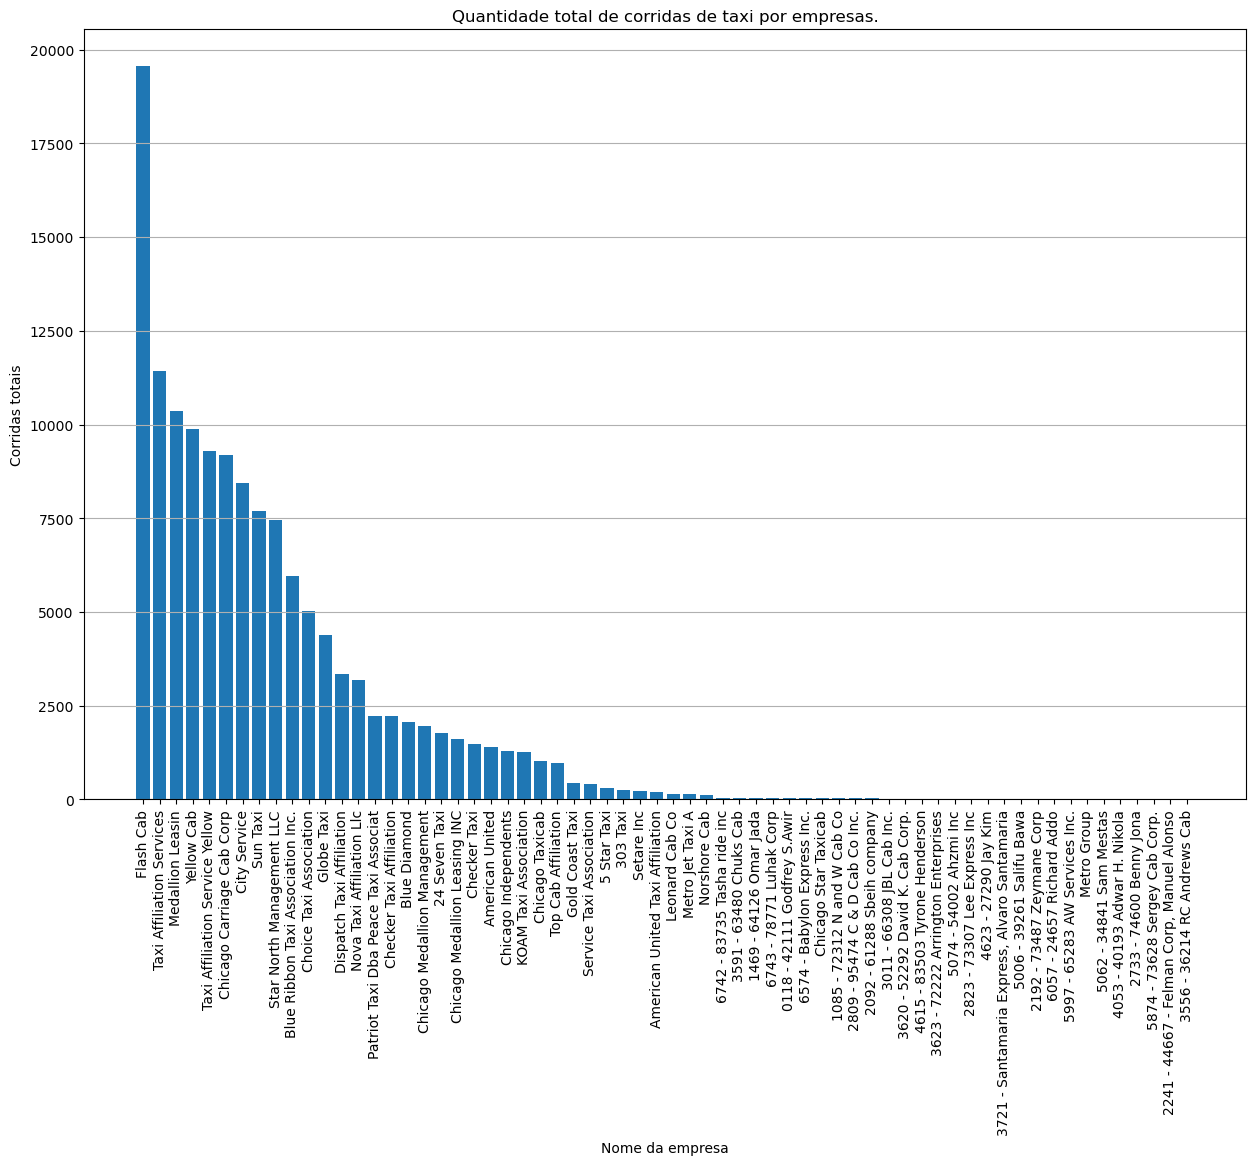

                        company_name  trips_amount
0                          Flash Cab         19558
1          Taxi Affiliation Services         11422
2                   Medallion Leasin         10367
3                         Yellow Cab          9888
4    Taxi Affiliation Service Yellow          9299
5          Chicago Carriage Cab Corp          9181
6                       City Service          8448
7                           Sun Taxi          7701
8          Star North Management LLC          7455
9  Blue Ribbon Taxi Association Inc.          5953


In [13]:
#Cria um gráfico de barras para analisar quais empresas possuem mais viagens

df_sorted_trips = df_trips.sort_values(by = 'trips_amount', ascending = False)

plt.figure(figsize = (15, 10))
plt.bar(df_sorted_trips['company_name'], df_sorted_trips['trips_amount'])
plt.title('Quantidade total de corridas de taxi por empresas.')
plt.xlabel('Nome da empresa')
plt.xticks(rotation = 90)
plt.ylabel('Corridas totais')
plt.grid(axis = 'y')
plt.show()

print(df_sorted_trips.head(10))

### GRÁFICO 2: TOP 10 BAIRROS POR NÚMERO DE DESTINO DAS CORRIDAS.

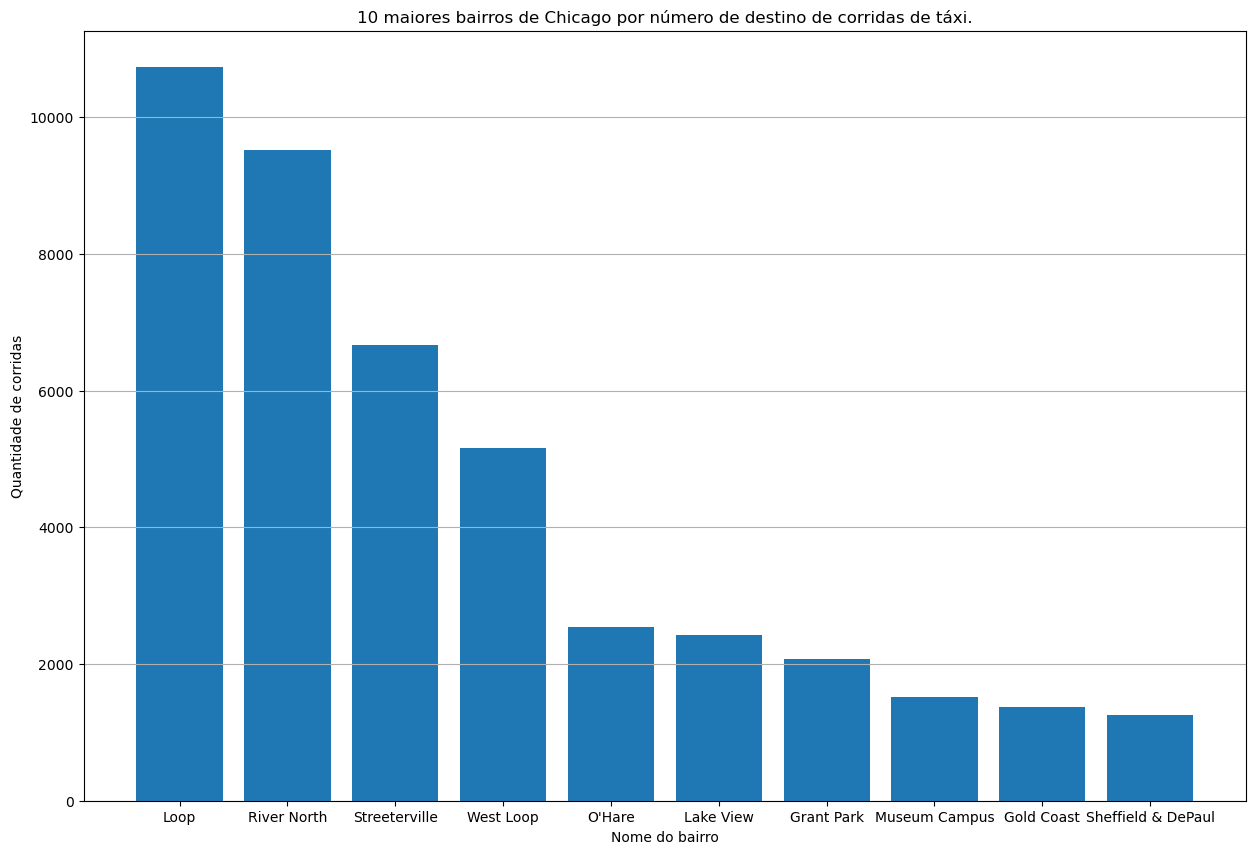

In [14]:
#Vamos reaproveitar o dataframe 'neighborhoods_top_10' para criar este gráfico.

plt.figure(figsize = (15, 10))
plt.bar(neighborhoods_top_10['dropoff_location_name'], neighborhoods_top_10['average_trips'])
plt.title('10 maiores bairros de Chicago por número de destino de corridas de táxi.')
plt.xlabel('Nome do bairro')
plt.ylabel('Quantidade de corridas')
plt.grid(axis = 'y')
plt.show()

# Conclusões dos gráficos:

**Analizando os gráficos, podemos chegar as seguintes conclusões:**

**As 5 maiores empresas de táxi de Chicago na questão de corridas feitas nos dias 15 e 16 de novembro de 2017 é a Flash Cab, tendo 80 mil viagens realizadas a mais do que a segunda colocada, a Taxi Affiliation Services, e depois da duas temos a Medallion Leasing, a Yellow Cab e a Taxi Affiliation Service Yellow.**

**Dos 10 bairros com mais destinos de corridas de taxi em Chicago, os 3 maiores deles são o Loop, River North e Streeterville e os 3 menores são Museum Campus, Gold Coast e por último Sheffield & DePaul.**

# ETAPA 4: Testando a hipótese.

**Com os dados prontos, agora será testada a seguinte hipótese:**

**HIPÓTESE:**

**A duração média dos passeios do Loop para o Aeroporto Internacional O'Hare muda nos sábados chuvosos.**

**HIPÓTESE NULA: A duração média dos passeios do Loop para o Aeroporto Internacional O'Hare muda nos sábados chuvosos.**

**HIPÓTESE ALTERNATIVA: A duração média dos passeios do Loop para o Aeroporto Internacional O'Hare não muda nos sábados chuvosos.**

**O nível de significância (alpha) escolhido é 0.05, ou seja, estamos dispostos a aceitar uma chance de 5% de erro Tipo I, ou seja, uma chance de 5% de rejeitar a hipótese nula quando ela é, na verdade, verdadeira.**

In [15]:
#Conta a quantidade de linhas do dataframe que cuja data seja em um sábado para garantir que não haja necessidade de filtrar por dia da semana
count_saturdays = df_trips_climate[df_trips_climate['start_ts'].dt.dayofweek == 5].count()

print(count_saturdays)

start_ts              871
weather_conditions    871
duration_seconds      871
dtype: int64


**Podemos ver que todos os dias registrados em "df_trips_climate" são sábados, ou seja, não será necessário filtrar os dados para o teste da hipótese.**

In [16]:
#TESTE DA HIPÓTESE

#1. Filtrar os dados de sábados chuvosos e dos demais sábados
saturdays_bad_weather = df_trips_climate[(df_trips_climate['weather_conditions'] == 'Bad')]['duration_seconds']
other_days = df_trips_climate[(df_trips_climate['weather_conditions'] == 'Good')]['duration_seconds']

#2. Determinar alpha
alpha = 0.05

#3. Verificar se há igualdade de variâncias usando o teste de Levene
levene_test_stat, levene_p_value = st.levene(saturdays_bad_weather, other_days)

print(f'A variância da média de passeios do Loop até o Aeroporto Internacional O´Hare em sábados chuvosos é: {saturdays_bad_weather.var()}')
print(f'A variância da média de passeios do Loop até o Aeroporto Internacional O´Hare em outros dias é: {other_days.var()}')
print(f'O valor-p do Teste de Levene para igualdade de variâncias é: {levene_p_value}')

equal_variances = False
if levene_p_value > alpha:
    equal_variances = True
    print('Assumimos variâncias iguais para o teste t (p-valor de Levene > alpha)')
else:
    print('Assumimos variâncias desiguais para o teste t (p-valor de Levene <= alpha)')

#Como estamos comparando as médias vindas de condições de data e clima diferentes sem nenhuma relação, faremos um teste t independente
#4. Realizar um teste t independente para testar as hipóteses
results = st.ttest_ind(saturdays_bad_weather, other_days, equal_var = equal_variances)

print('Valor-p:', results.pvalue)
if results.pvalue < alpha:
    print('Rejeitamos a hipótese nula')
    print('As médias da viagens em sábados chuvosos e em sábados com condições climáticas diferentes são muito próximas.')
else:
    print('Não podemos rejeitar a hipótese nula')
    print('Existe uma diferença significativa na média das viajens de táxi em sábados chuvosos se comparado a média vinda de sábados com climáticas diferentes.')

A variância da média de passeios do Loop até o Aeroporto Internacional O´Hare em sábados chuvosos é: 564819.4434638721
A variância da média de passeios do Loop até o Aeroporto Internacional O´Hare em outros dias é: 598216.9510810219
O valor-p do Teste de Levene para igualdade de variâncias é: 0.9806770360671218
Assumimos variâncias iguais para o teste t (p-valor de Levene > alpha)
Valor-p: 7.397770692813658e-08
Rejeitamos a hipótese nula
As médias da viagens em sábados chuvosos e em sábados com condições climáticas diferentes são muito próximas.
